In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [18]:
DEFAULT_ELO = 1500
SENS = 400

K_MAP = {
    'FIFA World Cup':               60,
    'UEFA Euro':                    50,
    'Copa América':                 45,
    'AFC Asian Cup':                40,
    'AFCON'                :        40,
    'CONCACAF Gold Cup':            40,
    'UEFA Nations League':          40,
    'FIFA World Cup qualification': 30,
    'UEFA Euro qualification':      25,
    'Copa América qualification':   20,
    'AFC Asian Cup qualification':  20,
    'AFCON qualification'         : 20,
    'Friendly':                     10,
}

DEFAULT_K = 30   # fallback for any tournament type not listed above
HOME_ADVANTAGE = 100


def get_k(tournament: str) -> float:
    """Look up K-factor for a given tournament string."""
    for key in K_MAP:
        if key.lower() in tournament.lower():
            return K_MAP[key]
    return DEFAULT_K


def expected_score(r_team: float, r_opp: float) -> float:
    """
    E = 1 / (1 + 10^((R_opp - R_team) / SENSITIVITY))

    This is the probability that r_team wins.
    e.g. if r_team=1800 and r_opp=1500:
         E = 1 / (1 + 10^(-300/400)) = ~0.85  (85% chance of winning)
    """
    return 1 / (1 + 10 ** ((r_opp - r_team) / SENS))

def mov_multiplier(goal_diff: int, elo_diff: float) -> float:
    """
    Adjusts the K-factor based on the margin of victory AND the existing
    strength gap to prevent inflation and 'underdog' jumping.
    """
    if goal_diff <= 1:
        return 1.0

    # 538 / World Football Elo approach:
    # increase the shift for big wins, but dampen it based on the Elo gap
    # The '0.65' and '0.001' are standard scaling constants
    return (1.75 + (goal_diff - 2) / 8.0) * (0.65 / (0.65 + (elo_diff * 0.001)))


def actual_score(home_goals: int, away_goals: int):
    """
    Returns (S_home, S_away) — the actual match outcome as Elo scores.
    Win = 1, Draw = 0.5, Loss = 0
    """
    if home_goals > away_goals:
        return 1.0, 0.0
    elif home_goals < away_goals:
        return 0.0, 1.0
    else:
        return 0.5, 0.5

def calculate_elo(df: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    """
    Scans all matches chronologically, maintaining a live ratings dict.
    Snapshots each team's Elo BEFORE the match (no data leakage),
    then updates ratings after.

    Returns:
      df       — dataframe with Elo columns attached
      ratings  — final ratings dict, use to predict future matches
    """
    df = df.sort_values('date').reset_index(drop=True)

    ratings = {}

    elo_home_pre  = []
    elo_away_pre  = []
    elo_home_post = []
    elo_away_post = []

    for _, row in df.iterrows():
        home = row['home_team']
        away = row['away_team']

        if home not in ratings:
            ratings[home] = DEFAULT_ELO
        if away not in ratings:
            ratings[away] = DEFAULT_ELO

        R_home = ratings[home]
        R_away = ratings[away]

        elo_home_pre.append(R_home)
        elo_away_pre.append(R_away)

        # apply home advantage when match is NOT on neutral ground
        # neutral=True means no home advantage (all WC matches, most tournaments) - thankfully dataset handles host nations stuffs
        # neutral=False means home team gets a virtual Elo boost for win probability only
        # important: this only affects E (expected score), NOT the stored ratings themselves
        is_neutral = row['neutral']
        R_home_adj = R_home + (0 if is_neutral else HOME_ADVANTAGE)
        E_home = expected_score(R_home_adj, R_away)
        E_away = 1 - E_home   # must sum to 1

        S_home, S_away = actual_score(row['home_score'], row['away_score'])

        K = get_k(row['tournament'])
        goal_diff = abs(row['home_score'] - row['away_score'])
        current_elo_diff = R_home - R_away if S_home > S_away else R_away - R_home

        K_eff = K * mov_multiplier(goal_diff, current_elo_diff)

        ratings[home] = R_home + K_eff * (S_home - E_home)
        ratings[away] = R_away + K_eff * (S_away - E_away)

        elo_home_post.append(ratings[home])
        elo_away_post.append(ratings[away])

    df['elo_home']      = elo_home_pre
    df['elo_away']      = elo_away_pre
    df['elo_diff']      = df['elo_home'] - df['elo_away']
    df['elo_home_post'] = elo_home_post
    df['elo_away_post'] = elo_away_post

    return df, ratings


if __name__ == '__main__':
    df = pd.read_csv('dataset/results.csv', parse_dates=['date'])
    print(f"Loaded {len(df)} matches ({df['date'].min().year}–{df['date'].max().year})")

    df, final_ratings = calculate_elo(df)

    top15 = sorted(final_ratings.items(), key=lambda x: x[1], reverse=True)[:15]
    print("\nTop 15 teams by final Elo:")
    for team, elo in top15:
        print(f"  {team:<25} {elo:.1f}")

    wc2018 = df[
        (df['date'] >= '2018-06-14') &
        (df['date'] <= '2018-07-15') &
        (df['tournament'] == 'FIFA World Cup')
    ]
    print(f"\n2018 World Cup matches in dataset: {len(wc2018)}")
    print(wc2018[['date','home_team','away_team','home_score','away_score','elo_diff']].to_string())

    df.to_csv('dataset/results_with_elo.csv', index=False)
    print("\nSaved → dataset/results_with_elo.csv")



Loaded 49071 matches (1872–2026)

Top 15 teams by final Elo:
  Spain                     2172.9
  Argentina                 2086.6
  England                   2071.6
  France                    2052.2
  Ecuador                   2003.7
  Colombia                  1995.2
  Norway                    1992.2
  Brazil                    1968.8
  Croatia                   1960.0
  Netherlands               1957.3
  Paraguay                  1945.7
  Japan                     1944.5
  Uruguay                   1932.4
  Senegal                   1922.8
  Germany                   1913.2

2018 World Cup matches in dataset: 64
            date     home_team     away_team  home_score  away_score    elo_diff
41605 2018-06-14        Russia  Saudi Arabia           5           0   22.321655
41606 2018-06-15         Egypt       Uruguay           0           1 -184.133473
41607 2018-06-15       Morocco          Iran           0           1  -72.399725
41608 2018-06-15      Portugal         Spain       

In [19]:
df['elo_home'].max()

#mov dampener update brought it down 200 pts on max and t15!


2242.209095628585

In [31]:
import pandas as pd
import numpy as np
#creating features

def make_team_match_df(df: pd.DataFrame) -> pd.DataFrame:
    #makes it from one row per match to two rows per match
    #outputs: date,team,opponent,goals_for,goals_against, goal_diff,win,draw,loss,points,torunament

    home = df[['date','home_team','away_team','home_score','away_score','tournament','neutral']].copy()
    home.columns = ['date','team','opponent','goals_for','goals_against','tournament','neutral']

    away = df[['date','away_team','home_team','away_score','home_score','tournament','neutral']].copy()
    away.columns = ['date','team','opponent','goals_for','goals_against','tournament','neutral']

    tm = pd.concat([home, away], ignore_index=True)
    tm = tm.sort_values(['team', 'date']).reset_index(drop=True)

    tm['goal_diff'] = tm['goals_for'] - tm['goals_against']
    tm['win']       = (tm['goal_diff'] > 0).astype(int)
    tm['draw']      = (tm['goal_diff'] == 0).astype(int)
    tm['loss']      = (tm['goal_diff'] < 0).astype(int)
    tm['points']    = tm['win'] * 3 + tm['draw'] * 1   # standard football points

    return tm

def add_rolling_form(tm: pd.DataFrame, windows=[5, 10, 20]) -> pd.DataFrame:

    """
    For each window size N get the rolling stats:
      win_rate_N        — fraction of last N matches won
      goals_for_avg_N   — avg goals scored per game over last N
      goals_against_avg_N — avg goals conceded per game over last N
      goal_diff_avg_N   — avg goal difference per game over last N
      points_pg_N       — avg points per game over last N (3=win,1=draw,0=loss)
    """

    tm = tm.sort_values(['team', 'date']).copy()

    for N in windows:
        grp = tm.groupby('team')

        # shift(1) so current match is never in its own rolling window
        tm[f'win_rate_{N}']          = grp['win'].transform(lambda x: x.shift(1).rolling(N, min_periods=1).mean())
        tm[f'goals_for_avg_{N}']     = grp['goals_for'].transform(lambda x: x.shift(1).rolling(N, min_periods=1).mean())
        tm[f'goals_against_avg_{N}'] = grp['goals_against'].transform(lambda x: x.shift(1).rolling(N, min_periods=1).mean())
        tm[f'goal_diff_avg_{N}']     = grp['goal_diff'].transform(lambda x: x.shift(1).rolling(N, min_periods=1).mean())
        tm[f'points_pg_{N}']         = grp['points'].transform(lambda x: x.shift(1).rolling(N, min_periods=1).mean())

    return tm

#stddev of goals scored in last 10 games
def add_goal_volatility(tm: pd.DataFrame, window=10) -> pd.DataFrame:
    tm = tm.sort_values(['team', 'date']).copy()
    tm[f'goal_volatility_{window}'] = (
        tm.groupby('team')['goals_for']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=3).std())
    )
    return tm
#ratio of last n games where no goals were conceded by team
def add_clean_sheet_ratio(tm: pd.DataFrame, window=10) -> pd.DataFrame:
    tm = tm.sort_values(['team', 'date']).copy()
    tm['clean_sheet'] = (tm['goals_against'] == 0).astype(int)
    tm[f'clean_sheet_ratio_{window}'] = (
        tm.groupby('team')['clean_sheet']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    )
    return tm


#elo delta from N matches
def add_elo_delta(df: pd.DataFrame, windows=[5, 10]) -> pd.DataFrame:
    home_elo = df[['date','home_team','elo_home_post']].rename(columns={'home_team':'team','elo_home_post':'elo_post'})
    away_elo = df[['date','away_team','elo_away_post']].rename(columns={'away_team':'team','elo_away_post':'elo_post'})
    elo_timeline = pd.concat([home_elo, away_elo]).sort_values(['team','date'])

    for N in windows:
        # elo N matches ago per team
        elo_timeline[f'elo_{N}ago'] = elo_timeline.groupby('team')['elo_post'].shift(N)
        elo_timeline[f'elo_delta_{N}'] = elo_timeline['elo_post'] - elo_timeline[f'elo_{N}ago']

    # merge back onto match-level df for home and away separately
    for N in windows:
        delta_lookup = elo_timeline[['date','team',f'elo_delta_{N}']].copy()

        home_delta = delta_lookup.rename(columns={'team':'home_team', f'elo_delta_{N}': f'elo_delta_home_{N}'})
        away_delta = delta_lookup.rename(columns={'team':'away_team', f'elo_delta_{N}': f'elo_delta_away_{N}'})

        df = df.merge(home_delta, on=['date','home_team'], how='left')
        df = df.merge(away_delta, on=['date','away_team'], how='left')

    return df

#find all previous meetings of the same two teams and gets the home winrate, avg gd, last 5 meetings, total games
def add_h2h(df: pd.DataFrame) -> pd.DataFrame:

    df = df.sort_values('date').reset_index(drop=True)

    h2h_winrate      = []
    h2h_gd_avg       = []
    h2h_last5_winrate= []
    h2h_count        = []

    for i, row in df.iterrows():
        home = row['home_team']
        away = row['away_team']

        # all previous meetings between these two teams (either direction)
        past = df.iloc[:i][
            ((df.iloc[:i]['home_team'] == home) & (df.iloc[:i]['away_team'] == away)) |
            ((df.iloc[:i]['home_team'] == away) & (df.iloc[:i]['away_team'] == home))
        ].copy()

        if len(past) == 0:
            h2h_winrate.append(0.5)       # no history — assume 50/50
            h2h_gd_avg.append(0.0)
            h2h_last5_winrate.append(0.5)
            h2h_count.append(0)
            continue

        # from home team's perspective
        past['home_won'] = (
            ((past['home_team'] == home) & (past['home_score'] > past['away_score'])) |
            ((past['away_team'] == home) & (past['away_score'] > past['home_score']))
        ).astype(int)

        past['home_gd'] = np.where(
            past['home_team'] == home,
            past['home_score'] - past['away_score'],
            past['away_score'] - past['home_score']
        )

        h2h_winrate.append(past['home_won'].mean())
        h2h_gd_avg.append(past['home_gd'].mean())
        h2h_last5_winrate.append(past['home_won'].tail(5).mean())
        h2h_count.append(len(past))

    df['h2h_home_winrate']      = h2h_winrate
    df['h2h_home_gd_avg']       = h2h_gd_avg
    df['h2h_last5_home_winrate']= h2h_last5_winrate
    df['h2h_matches_played']    = h2h_count

    return df

#days of rest for a team, caps at 365
def add_days_rest(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values('date').reset_index(drop=True)

    # track last match date per team as we scan forward
    last_played = {}
    days_rest_home = []
    days_rest_away = []

    for _, row in df.iterrows():
        home = row['home_team']
        away = row['away_team']
        date = row['date']

        # days since home team last played
        if home in last_played:
            days_rest_home.append(min((date - last_played[home]).days, 365))
        else:
            days_rest_home.append(np.nan)   # first ever match — no prior rest to measure

        # days since away team last played
        if away in last_played:
            days_rest_away.append(min((date - last_played[away]).days, 365))
        else:
            days_rest_away.append(np.nan)

        # update last played for both teams
        last_played[home] = date
        last_played[away] = date

    df['days_rest_home'] = days_rest_home
    df['days_rest_away'] = days_rest_away
    df['days_rest_diff'] = df['days_rest_home'] - df['days_rest_away']  # positive = home more rested

    return df

TOURNAMENT_WEIGHT = {
    'FIFA World Cup':                5,
    'UEFA Euro':                     4,
    'Copa América':                  4,
    'AFC Asian Cup':                 3,
    'Africa Cup of Nations':         3,
    'CONCACAF Gold Cup':             3,
    'UEFA Nations League':           3,
    'CONCACAF Nations League':       3,
    'FIFA World Cup qualification':  2,
    'UEFA Euro qualification':       2,
    'Copa América qualification':    2,
    'AFC Asian Cup qualification':   2,
    'AFCON qualification':           2,
    'Friendly':                      1,
}

def add_tournament_weight(df: pd.DataFrame) -> pd.DataFrame:
    def get_weight(t):
        t_lower = t.lower()
        for key, val in TOURNAMENT_WEIGHT.items():
            if key.lower() in t_lower:
                return val
        return 2   # default — unknown tournament, treat as qualifier-level

    df['tournament_weight'] = df['tournament'].apply(get_weight)
    return df

CONFEDERATION_MAP = {
    # UEFA — Europe
    'England': 'UEFA', 'France': 'UEFA', 'Germany': 'UEFA', 'Spain': 'UEFA',
    'Italy': 'UEFA', 'Portugal': 'UEFA', 'Netherlands': 'UEFA', 'Belgium': 'UEFA',
    'Croatia': 'UEFA', 'Denmark': 'UEFA', 'Sweden': 'UEFA', 'Norway': 'UEFA',
    'Switzerland': 'UEFA', 'Austria': 'UEFA', 'Poland': 'UEFA', 'Czech Republic': 'UEFA',
    'Turkey': 'UEFA', 'Serbia': 'UEFA', 'Ukraine': 'UEFA', 'Russia': 'UEFA',
    # CONMEBOL — South America
    'Brazil': 'CONMEBOL', 'Argentina': 'CONMEBOL', 'Uruguay': 'CONMEBOL',
    'Colombia': 'CONMEBOL', 'Chile': 'CONMEBOL', 'Peru': 'CONMEBOL',
    'Ecuador': 'CONMEBOL', 'Paraguay': 'CONMEBOL', 'Bolivia': 'CONMEBOL',
    'Venezuela': 'CONMEBOL',
    # CONCACAF — North/Central America + Caribbean
    'Mexico': 'CONCACAF', 'United States': 'CONCACAF', 'Costa Rica': 'CONCACAF',
    'Panama': 'CONCACAF', 'Honduras': 'CONCACAF', 'Jamaica': 'CONCACAF',
    'Canada': 'CONCACAF', 'Trinidad and Tobago': 'CONCACAF',
    # CAF — Africa
    'Morocco': 'CAF', 'Senegal': 'CAF', 'Nigeria': 'CAF', 'Ghana': 'CAF',
    'Cameroon': 'CAF', 'Egypt': 'CAF', 'Tunisia': 'CAF', 'Algeria': 'CAF',
    'Ivory Coast': 'CAF', 'Mali': 'CAF', 'South Africa': 'CAF',
    # AFC — Asia
    'Japan': 'AFC', 'South Korea': 'AFC', 'Iran': 'AFC', 'Saudi Arabia': 'AFC',
    'Australia': 'AFC', 'China PR': 'AFC', 'Qatar': 'AFC', 'Iraq': 'AFC',
    'Uzbekistan': 'AFC', 'Jordan': 'AFC',
    # OFC — Oceania
    'New Zealand': 'OFC',
}


CONF_ENCODING = {'UEFA': 0, 'CONMEBOL': 1, 'CONCACAF': 2, 'CAF': 3, 'AFC': 4, 'OFC': 5, 'UNKNOWN': 6}

def add_confederation(df: pd.DataFrame) -> pd.DataFrame:
    df['conf_home'] = df['home_team'].map(CONFEDERATION_MAP).fillna('UNKNOWN').map(CONF_ENCODING)
    df['conf_away'] = df['away_team'].map(CONFEDERATION_MAP).fillna('UNKNOWN').map(CONF_ENCODING)
    df['same_conf'] = (df['conf_home'] == df['conf_away']).astype(int)  # 1 if same confederation
    return df

#master function  -
# Runs all feature engineering steps in the correct order. preparation for xGboost
"""
def build_features(df: pd.DataFrame) -> pd.DataFrame:

    print("Building team-match view for rolling features...")
    tm = make_team_match_df(df)

    print("Adding rolling form windows (5, 10, 20 matches)...")
    tm = add_rolling_form(tm, windows=[5, 10, 20])

    print("Adding goal volatility...")
    tm = add_goal_volatility(tm, window=10)

    print("Adding clean sheet ratio...")
    tm = add_clean_sheet_ratio(tm, window=10)

    # merge rolling features back onto match-level df (home + away separately)
    rolling_cols = [c for c in tm.columns if any(c.startswith(p) for p in
                   ['win_rate','goals_for_avg','goals_against_avg',
                    'goal_diff_avg','points_pg','goal_volatility','clean_sheet_ratio'])]

    # drop duplicates before merging — rare cases of same team playing twice on same date
    tm_dedup = tm.drop_duplicates(subset=['date','team'], keep='last')

    home_stats = tm_dedup[['date','team'] + rolling_cols].copy()
    away_stats = tm_dedup[['date','team'] + rolling_cols].copy()

    home_stats = home_stats.rename(columns={'team': 'home_team'} |
                                   {c: f'{c}_home' for c in rolling_cols})
    away_stats = away_stats.rename(columns={'team': 'away_team'} |
                                   {c: f'{c}_away' for c in rolling_cols})

    df = df.merge(home_stats, on=['date','home_team'], how='left')
    df = df.merge(away_stats, on=['date','away_team'], how='left')

    print("Adding Elo delta (momentum)...")
    df = add_elo_delta(df, windows=[5, 10])

    print("Adding head-to-head features...")
    df = add_h2h(df)

    print("Adding days rest...")
    df = add_days_rest(df)

    print("Adding tournament weight...")
    df = add_tournament_weight(df)

    print("Adding confederation encoding...")
    df = add_confederation(df)

    # neutral ground as int (XGBoost needs numbers)
    df['is_neutral'] = df['neutral'].astype(int)

    print(f"\nDone. Feature df shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")

    return df
    """
    #n^2 so gotta figure out smth else or run it later. v1 without it

#classification target for win/draw/loss:
def add_target(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds result column: 'H' = home win, 'D' = draw, 'A' = away win
    Use this for classification evaluation later.
    """
    def get_result(row):
        if row['home_score'] > row['away_score']:   return 'H'
        elif row['home_score'] < row['away_score']: return 'A'
        else:                                        return 'D'
    df['result'] = df.apply(get_result, axis=1)
    return df

Loaded 49071 matches (1872–2026)

Building features...
Feature df shape: (50379, 61)
All 49 feature columns present

Train size:       42,901 matches
Test 2018 WC:     64 matches
Test 2022 WC:     64 matches
Train after dropna: 40,430 matches

Training XGBoost regressors...
Done training.

WC 2018
Matches evaluated:  64
Result accuracy:    47/64 (73.4%)
MAE home goals:     0.816
MAE away goals:     0.665

Match-by-match predictions:
Date         Home                   Away                     Pred  Actual ✓
--------------------------------------------------------------------------------
2018-06-14   Russia                 Saudi Arabia              3-0     5-0  ✓
2018-06-15   Egypt                  Uruguay                   1-2     0-1  ✓
2018-06-15   Morocco                Iran                      0-2     0-1  ✓
2018-06-15   Portugal               Spain                     1-2     3-3  ✗
2018-06-16   Peru                   Denmark                   0-2     0-1  ✓
2018-06-16   Croatia 

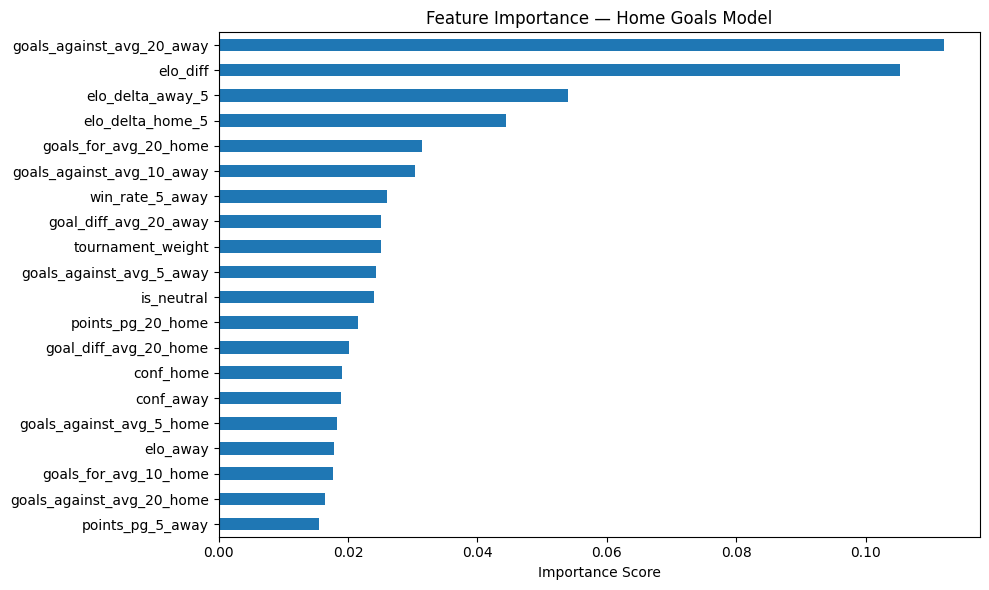

Saved feature_importance.png


In [34]:
#train and call everything

import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

#elo

df = pd.read_csv('dataset/results.csv', parse_dates=['date'])
print(f"Loaded {len(df)} matches ({df['date'].min().year}–{df['date'].max().year})")

df, final_ratings = calculate_elo(df)
df = add_target(df)

#features w/o h2h

print("\nBuilding features...")
tm = make_team_match_df(df)
tm = add_rolling_form(tm, windows=[5, 10, 20])
tm = add_goal_volatility(tm, window=10)
tm = add_clean_sheet_ratio(tm, window=10)

rolling_cols = [c for c in tm.columns if any(c.startswith(p) for p in
               ['win_rate','goals_for_avg','goals_against_avg',
                'goal_diff_avg','points_pg','goal_volatility','clean_sheet_ratio'])]

tm_dedup = tm.drop_duplicates(subset=['date','team'], keep='last')
home_stats = tm_dedup[['date','team'] + rolling_cols].rename(
    columns={'team':'home_team'} | {c: f'{c}_home' for c in rolling_cols})
away_stats = tm_dedup[['date','team'] + rolling_cols].rename(
    columns={'team':'away_team'} | {c: f'{c}_away' for c in rolling_cols})

df = df.merge(home_stats, on=['date','home_team'], how='left')
df = df.merge(away_stats, on=['date','away_team'], how='left')
df = add_elo_delta(df, windows=[5, 10])
df = add_days_rest(df)
df = add_tournament_weight(df)
df = add_confederation(df)
df['is_neutral'] = df['neutral'].astype(int)

print(f"Feature df shape: {df.shape}")

#feature cols

FEATURE_COLS = [
    # elo
    'elo_home', 'elo_away', 'elo_diff',
    'elo_delta_home_5', 'elo_delta_home_10',
    'elo_delta_away_5', 'elo_delta_away_10',

    # rolling form — home
    'win_rate_5_home', 'win_rate_10_home', 'win_rate_20_home',
    'goals_for_avg_5_home', 'goals_for_avg_10_home', 'goals_for_avg_20_home',
    'goals_against_avg_5_home', 'goals_against_avg_10_home', 'goals_against_avg_20_home',
    'goal_diff_avg_5_home', 'goal_diff_avg_10_home', 'goal_diff_avg_20_home',
    'points_pg_5_home', 'points_pg_10_home', 'points_pg_20_home',
    'goal_volatility_10_home',
    'clean_sheet_ratio_10_home',

    # rolling form — away
    'win_rate_5_away', 'win_rate_10_away', 'win_rate_20_away',
    'goals_for_avg_5_away', 'goals_for_avg_10_away', 'goals_for_avg_20_away',
    'goals_against_avg_5_away', 'goals_against_avg_10_away', 'goals_against_avg_20_away',
    'goal_diff_avg_5_away', 'goal_diff_avg_10_away', 'goal_diff_avg_20_away',
    'points_pg_5_away', 'points_pg_10_away', 'points_pg_20_away',
    'goal_volatility_10_away',
    'clean_sheet_ratio_10_away',

    # match context
    'is_neutral', 'tournament_weight',
    'days_rest_home', 'days_rest_away', 'days_rest_diff',

    # confederation
    'conf_home', 'conf_away', 'same_conf',
]

# verify all columns exist
missing = [c for c in FEATURE_COLS if c not in df.columns]
if missing:
    print(f"WARNING — missing columns: {missing}")
else:
    print(f"All {len(FEATURE_COLS)} feature columns present")

#train test
# train  = everything before WC 2018
# test18 = WC 2018 matches only
# test22 = WC 2022 matches only



train_df = df[df['date'] < '2018-06-14'].copy()
test18   = df[(df['tournament'] == 'FIFA World Cup') & (df['date'].dt.year == 2018)].copy()
test22   = df[(df['tournament'] == 'FIFA World Cup') & (df['date'].dt.year == 2022)].copy()

print(f"\nTrain size:       {len(train_df):,} matches")
print(f"Test 2018 WC:     {len(test18)} matches")
print(f"Test 2022 WC:     {len(test22)} matches")

# drop rows where features are NaN
# (early matches per team won't have rolling windows yet)
train_clean = train_df[FEATURE_COLS + ['home_score','away_score']].dropna()
print(f"Train after dropna: {len(train_clean):,} matches")

X_train = train_clean[FEATURE_COLS]
y_train_home = train_clean['home_score']
y_train_away = train_clean['away_score']


#two regressors
# one predicts home goals, one predicts away goals
# from scoreline you get win/draw/loss naturally

print("\nTraining XGBoost regressors...")

# sample weights — give more importance to recent matches
train_years = pd.to_datetime(train_clean['date'] if 'date' in train_clean.columns
                             else train_df.loc[train_clean.index, 'date'])
# re-attach date for weighting
train_clean = train_clean.copy()
train_clean['date'] = train_df.loc[train_clean.index, 'date']
min_year = train_clean['date'].dt.year.min()
max_year = train_clean['date'].dt.year.max()
sample_weights = 1 + 2 * (train_clean['date'].dt.year - min_year) / (max_year - min_year)
# this gives matches from min_year weight=1.0 and matches from max_year weight=3.0

xgb_home = XGBRegressor(
    n_estimators=500,       # number of trees
    max_depth=4,            # keep trees shallow — prevent noise
    learning_rate=0.05,     # small steps — more trees + small LR = better generalization
    subsample=0.8,          # each tree sees 80% of training rows (reduces overfitting)
    colsample_bytree=0.8,   # each tree sees 80% of features (reduces overfitting)
    random_state=42,
    verbosity=0
)

xgb_away = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)

xgb_home.fit(X_train, y_train_home, sample_weight=sample_weights)
xgb_away.fit(X_train, y_train_away, sample_weight=sample_weights)
print("Done training.")

#eval on wc18, wc22. use the real results post each round

def evaluate_wc(model_home, model_away, test_df, feature_cols, label):
    """
    For each match in test_df:
      - predict home and away goals
      - round to nearest int to get scoreline
      - derive predicted result (H/D/A)
      - compare to actual result
    """
    test_clean = test_df[feature_cols + ['home_score','away_score','result',
                                          'home_team','away_team','date']].dropna()

    X_test = test_clean[feature_cols]

    # raw predictions (floats like 1.7, 0.9)
    pred_home_raw = model_home.predict(X_test)
    pred_away_raw = model_away.predict(X_test)

    # clip to 0 minimum (can't have negative goals)
    pred_home_raw = np.clip(pred_home_raw, 0, None)
    pred_away_raw = np.clip(pred_away_raw, 0, None)

    # round to get integer scoreline
    pred_home = np.round(pred_home_raw).astype(int)
    pred_away = np.round(pred_away_raw).astype(int)

    # derive predicted result from scoreline
    def result_from_score(h, a):
        if h > a:   return 'H'
        elif h < a: return 'A'
        else:       return 'D'

    pred_results = [result_from_score(h, a) for h, a in zip(pred_home, pred_away)]
    actual_results = test_clean['result'].values

    # accuracy = fraction of matches where predicted result matches actual result
    correct = sum(p == a for p, a in zip(pred_results, actual_results))
    accuracy = correct / len(actual_results)

    # MAE on raw goal predictions (before rounding)
    mae_home = mean_absolute_error(test_clean['home_score'], pred_home_raw)
    mae_away = mean_absolute_error(test_clean['away_score'], pred_away_raw)

    print(f"\n{'='*50}")
    print(f"{label}")
    print(f"{'='*50}")
    print(f"Matches evaluated:  {len(actual_results)}")
    print(f"Result accuracy:    {correct}/{len(actual_results)} ({accuracy:.1%})")
    print(f"MAE home goals:     {mae_home:.3f}")
    print(f"MAE away goals:     {mae_away:.3f}")

    # show each match prediction vs actual
    print(f"\nMatch-by-match predictions:")
    print(f"{'Date':<12} {'Home':<22} {'Away':<22} {'Pred':>6} {'Actual':>7} {'✓'}")
    print("-" * 80)
    for i, (_, row) in enumerate(test_clean.iterrows()):
        ph, pa = pred_home[i], pred_away[i]
        ah, aa = int(row['home_score']), int(row['away_score'])
        pred_str   = f"{ph}-{pa}"
        actual_str = f"{ah}-{aa}"
        tick = "✓" if pred_results[i] == row['result'] else "✗"
        print(f"{str(row['date'].date()):<12} {row['home_team']:<22} {row['away_team']:<22} "
              f"{pred_str:>6} {actual_str:>7}  {tick}")

    return accuracy, pred_results, actual_results


acc18, _, _ = evaluate_wc(xgb_home, xgb_away, test18, FEATURE_COLS, "WC 2018")
acc22, _, _ = evaluate_wc(xgb_home, xgb_away, test22, FEATURE_COLS, "WC 2022")

#and  plot feature importance

print("\n\nTop 20 most important features (home goals model):")
importances = pd.Series(xgb_home.feature_importances_, index=FEATURE_COLS)
top20 = importances.sort_values(ascending=False).head(20)
print(top20.to_string())

# plot it
fig, ax = plt.subplots(figsize=(10, 6))
top20.sort_values().plot(kind='barh', ax=ax)
ax.set_title('Feature Importance — Home Goals Model')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("Saved feature_importance.png")